# Generating and analysing two synthetic audio signals

We build two 5‑second signals, one composed of clean harmonics and
another one containing narrow frequency peaks plus a noise floor, compute their FFTs and plot both
waveforms and spectra.

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# configure inline plotting for notebooks
%matplotlib inline


## Parameters and time axis

- `DURATION` in seconds
- `SAMPLE_RATE` in Hz
- `t` is the time vector used for all signal generation

In [41]:
DURATION = 5        # seconds
SAMPLE_RATE = 44100
t = np.linspace(0, DURATION, DURATION * SAMPLE_RATE, endpoint=False)


## Signal 1: clean harmonic components
We sum a few sinusoids and normalise the result.

In [42]:
frequencies = [6000, 10000, 15000]  # Hz
amplitudes = [0.5, 0.4, 0.3]
signal1 = np.zeros_like(t)
for freq, amp in zip(frequencies, amplitudes):
    signal1 += amp * np.sin(2 * np.pi * freq * t)

signal1 = signal1 / np.max(np.abs(signal1))  # normalise

## Signal 2: triangular peaks around the same centres plus noise
We create a small cluster of slightly offset frequencies around each centre to produce narrow
triangular peaks, add broadband Gaussian noise, then normalise.

In [43]:
frequencies = [6000, 10000, 15000]  # Hz
amplitudes = [0.4, 0.35, 0.3]
peak_width = 15  # Hz

signal2 = np.zeros_like(t)
for center_freq, amp in zip(frequencies, amplitudes):
    num_components = 9
    for offset in np.linspace(-peak_width, peak_width, num_components):
        weight = 1 - abs(offset) / peak_width
        freq = center_freq + offset
        signal2 += amp * weight * np.sin(2 * np.pi * freq * t + np.random.uniform(0, 2*np.pi))

# add broadband noise about 20% of peak amplitude
noise_amplitude = 0.25
signal2 += np.random.randn(len(t)) * noise_amplitude

signal2 = signal2 / np.max(np.abs(signal2))

Save as WAV files

In [44]:
# from scipy.io import wavfile

# signal1_int = np.int16(signal1 * 32767)
# signal2_int = np.int16(signal2 * 32767)
# AUDIO_OUT = "data/signals/"
# wavfile.write(os.path.join(AUDIO_OUT, "signal1_harmonics.wav"), SAMPLE_RATE, signal1_int)
# wavfile.write(os.path.join(AUDIO_OUT, "signal2_spikes_noise.wav"), SAMPLE_RATE, signal2_int)


## Compute FFTs
Use `rfft` because the signals are real; normalise by the number of samples.

In [45]:
n = len(t)
freq_axis = np.fft.rfftfreq(n, 1 / SAMPLE_RATE)

fft1 = np.abs(np.fft.rfft(signal1)) / n
fft2 = np.abs(np.fft.rfft(signal2)) / n

## Plot time‑domain waveforms and spectra
Show the first 50 ms of each signal and the corresponding FFT magnitudes.

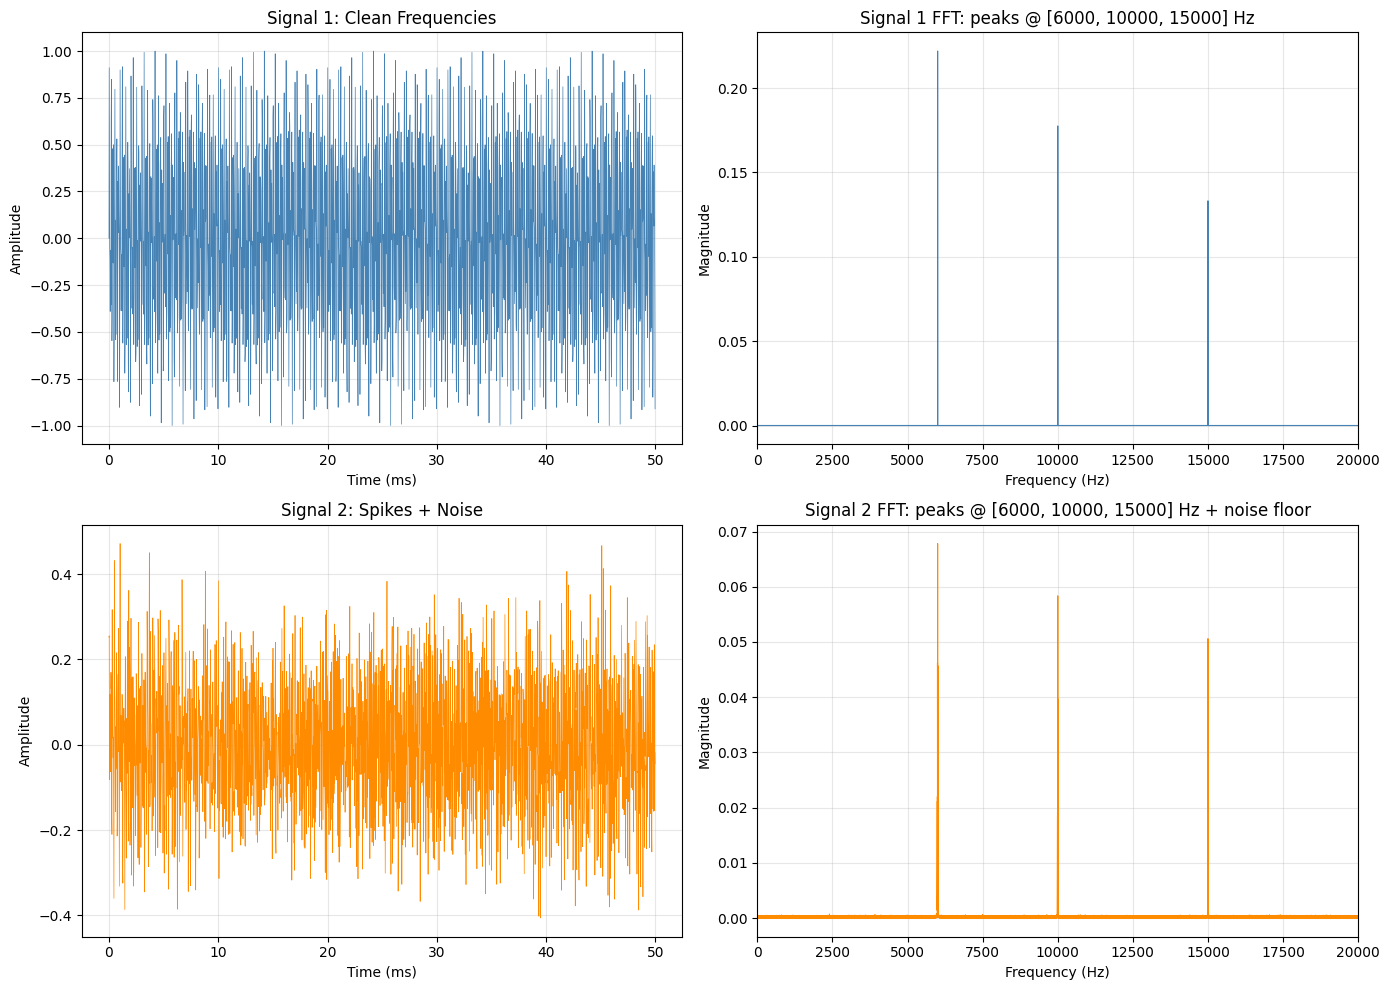

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
samples_to_show = int(0.05 * SAMPLE_RATE)

axes[0, 0].plot(t[:samples_to_show] * 1000, signal1[:samples_to_show],
                 color='steelblue', linewidth=0.5)
axes[0, 0].set_title("Signal 1: Clean Frequencies")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(freq_axis, fft1, color='steelblue', linewidth=0.8)
axes[0, 1].set_title(f"Signal 1 FFT: peaks @ {frequencies} Hz")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].set_xlim(0, 20000)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t[:samples_to_show] * 1000, signal2[:samples_to_show],
                 color='darkorange', linewidth=0.5)
axes[1, 0].set_title("Signal 2: Spikes + Noise")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(freq_axis, fft2, color='darkorange', linewidth=0.8)
axes[1, 1].set_title(f"Signal 2 FFT: peaks @ {frequencies} Hz + noise floor")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].set_xlim(0, 20000)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
